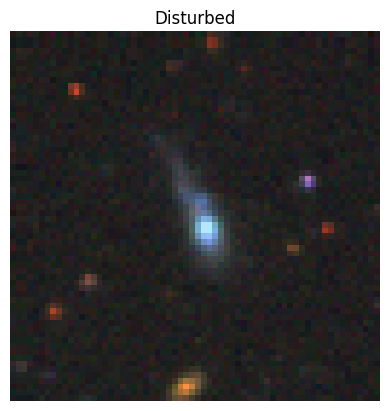

[[[36 25 23]
  [34 36 30]
  [25 34 25]
  ...
  [35 36 33]
  [33 16  4]
  [31 28 34]]

 [[19 25 28]
  [23 31 29]
  [22 29 27]
  ...
  [31 31 30]
  [26 26 39]
  [45 26 30]]

 [[21 22 23]
  [20 31 30]
  [18 28 27]
  ...
  [32 31 30]
  [31 25 30]
  [42 29 32]]

 ...

 [[30 24 26]
  [35 29 25]
  [32 25 23]
  ...
  [25 28 23]
  [29 34 31]
  [35 32 26]]

 [[11 39 32]
  [29 33 34]
  [23 35 32]
  ...
  [35 31 40]
  [30 26 26]
  [17 41 21]]

 [[31 26 33]
  [18 27 31]
  [21 28 32]
  ...
  [37 25 23]
  [25 27 29]
  [24 28 22]]]


In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Class names
CLASS_NAMES = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
    'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
    'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge'
]

# Load dataset
with h5py.File('Galaxy10_DECals_64x64.h5', 'r') as F:
    images = np.array(F['images'])   # shape: (17736, 64, 64, 3)
    labels = np.array(F['ans'])      # integer labels 0-9

# Display galaxy 27
plt.imshow(images[27] / 255.0)
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

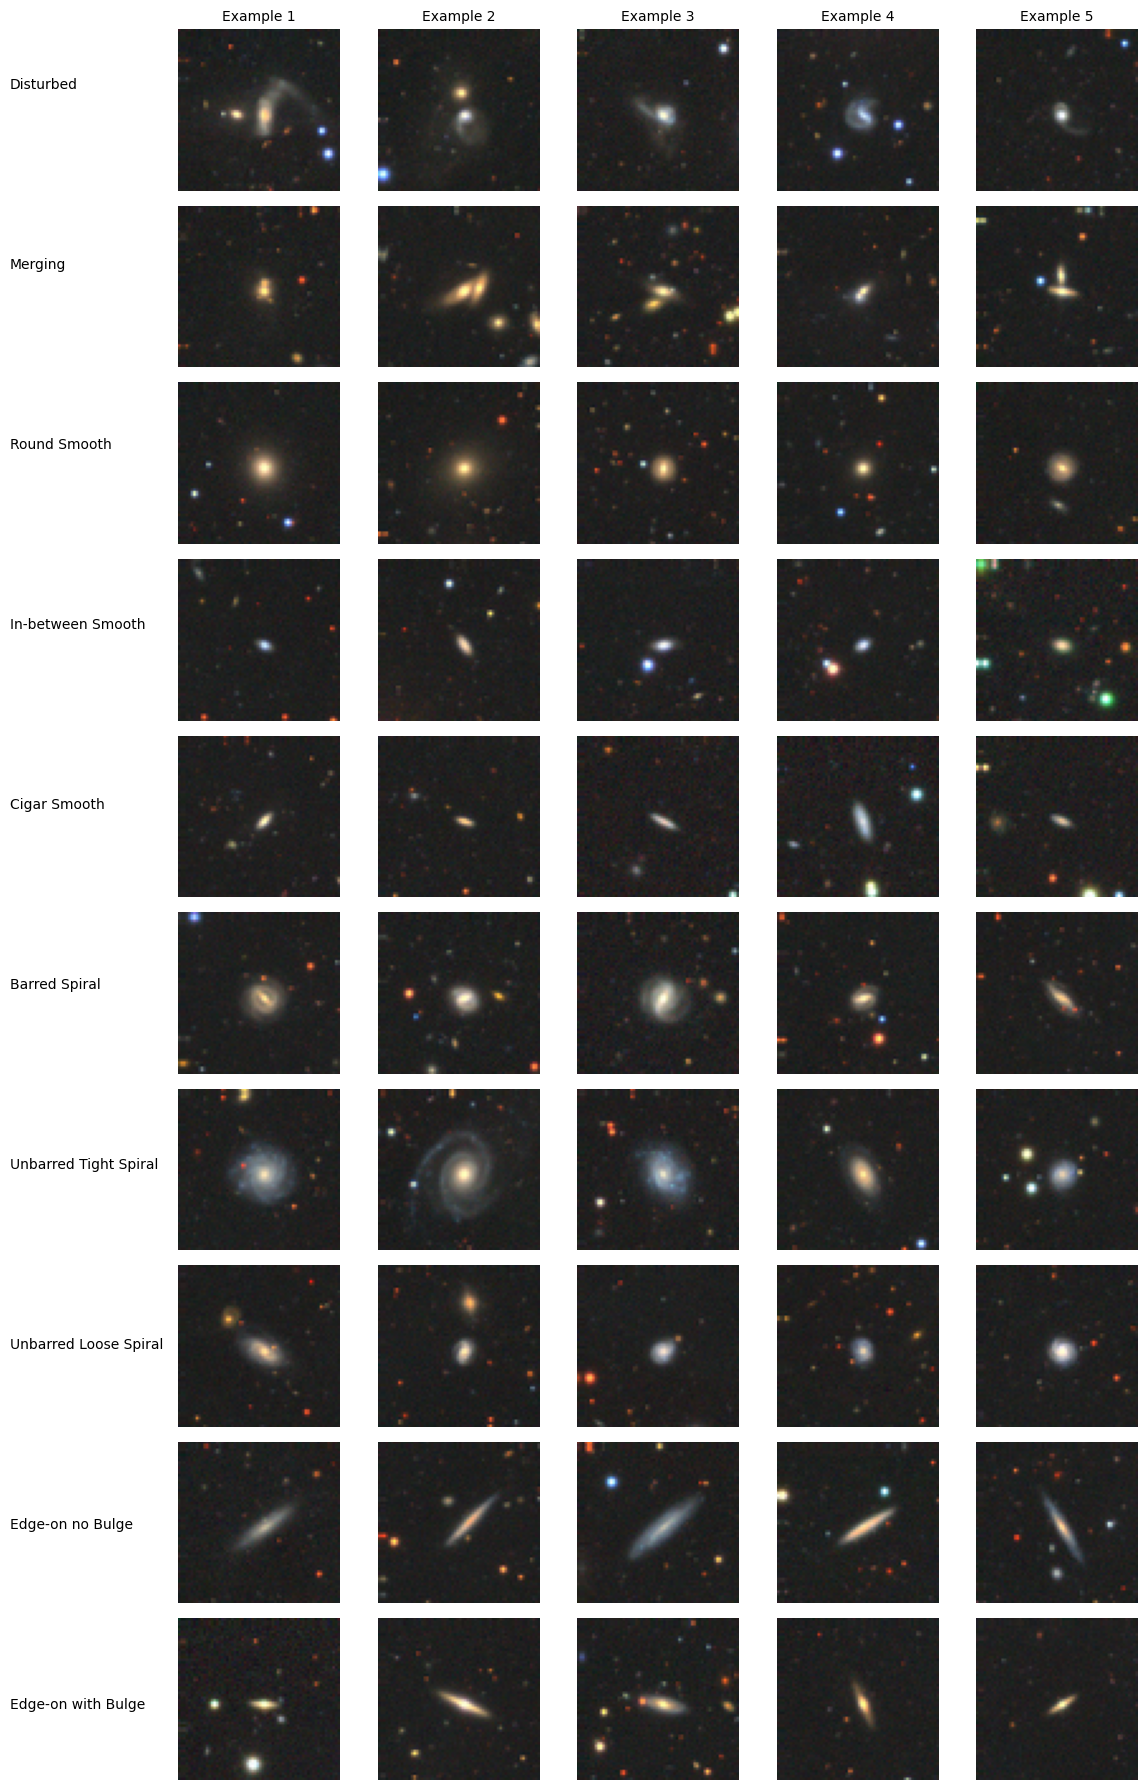

In [11]:
examples_per_class = 5
n_classes = 10

fig, axes = plt.subplots(n_classes, examples_per_class, figsize=( 12, 18))

for i in range(n_classes):
    idx = np.where(labels == i)[0][:examples_per_class]

    for j in range(examples_per_class):
        axes[i, j].imshow(images[idx[j]] / 255.0)
        axes[i, j].axis('off')

        if i == 0:
            axes[i, j].set_title(f'Example {j+1}', fontsize=10)

    fig.text(0.02, 1 - (i + 0.5) / n_classes, CLASS_NAMES[i], va='center', fontsize=10)

plt.tight_layout(rect=[0.12, 0, 1, 1])
plt.show()

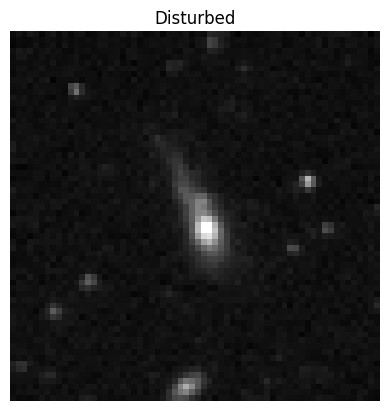

In [13]:
gray_images = np.mean(images, axis=-1)  # shape: (17736, 64, 64)
plt.imshow(gray_images[27], cmap='gray')
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

In [14]:
shape = gray_images.shape
print(f"Shape of grayscale images: {shape}")

Shape of grayscale images: (17736, 64, 64)


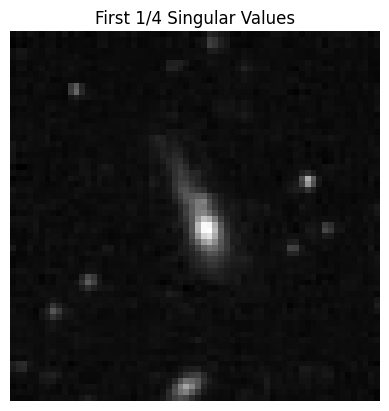

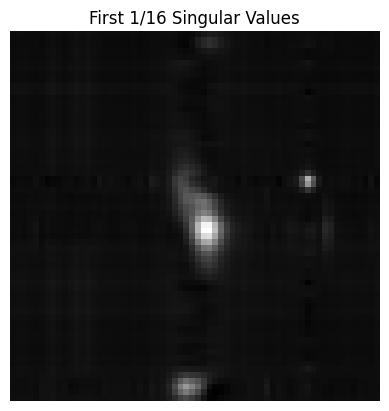

In [15]:
img = gray_images[27]  # shape (64, 64)
U, S, Vt = np.linalg.svd(img, full_matrices=False)

k = len(S) // 4
img_1_4 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_4, cmap="gray")
plt.title("First 1/4 Singular Values")  
plt.axis('off')
plt.show()
k = len(S) // 16
img_1_16 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_16, cmap="gray")
plt.title("First 1/16 Singular Values")
plt.axis('off')
plt.show()


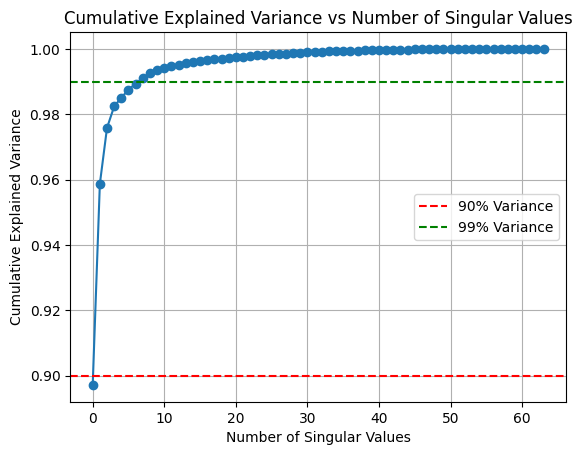

Number of singular values needed to explain 99% variance: 8
Number of singular values needed to explain 90% variance: 2


In [16]:
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1 
print(f"Number of singular values needed to explain 90% variance: {k_90}")

In [17]:
w_1 = 2.858
median = S[31]  # 32nd singular value (index 31)
print(f"32nd singular value: {median:.3f}")
index = 0
for sigma in S:
    index += 1
    if sigma > w_1 * median:
        print(f"{index}. Singular value {sigma:.3f} is larger than 2.858 * {median:.3f}")
    else:
        break   

32nd singular value: 23.668
1. Singular value 2239.678 is larger than 2.858 * 23.668
2. Singular value 586.648 is larger than 2.858 * 23.668
3. Singular value 309.465 is larger than 2.858 * 23.668
4. Singular value 191.425 is larger than 2.858 * 23.668
5. Singular value 123.098 is larger than 2.858 * 23.668
6. Singular value 115.918 is larger than 2.858 * 23.668
7. Singular value 103.269 is larger than 2.858 * 23.668
8. Singular value 96.053 is larger than 2.858 * 23.668
9. Singular value 89.299 is larger than 2.858 * 23.668
10. Singular value 71.305 is larger than 2.858 * 23.668


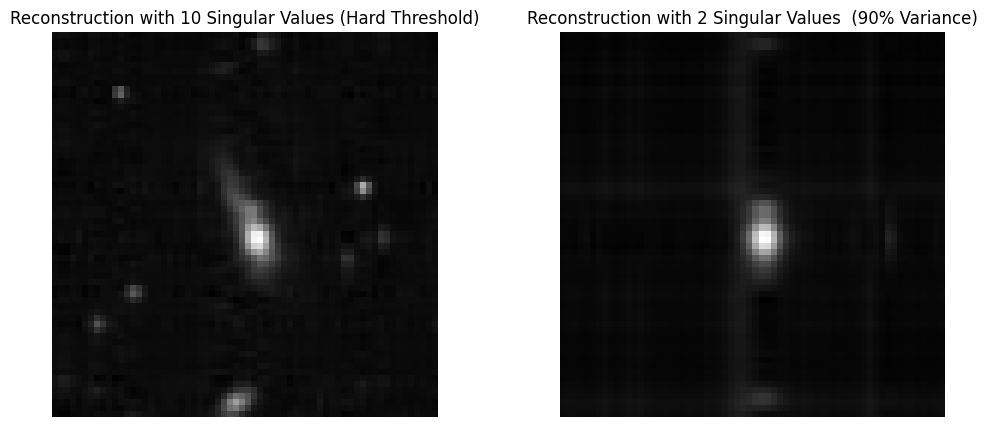

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
hard_threshold_reconstructed = U[:, :index-1] @ np.diag(S[:index-1]) @ Vt[:index-1, :]
axes[0].imshow(hard_threshold_reconstructed, cmap='gray')
axes[0].set_title(f"Reconstruction with {index-1} Singular Values (Hard Threshold)")
axes[0].axis('off')
Ninety_reconstructed = U[:, :k_90] @ np.diag(S[:k_90]) @ Vt[:k_90, :]
axes[1].imshow(Ninety_reconstructed, cmap='gray')   
axes[1].set_title(f"Reconstruction with {k_90} Singular Values  (90% Variance)")
axes[1].axis('off')
plt.show()


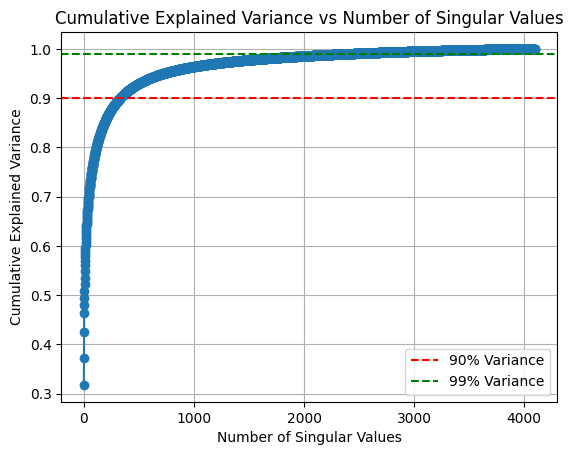

Number of singular values needed to explain 99% variance: 2387
Number of singular values needed to explain 90% variance: 329


In [23]:
flat_x = gray_images.reshape(gray_images.shape[0], -1)  # shape: (17736, 4096)
xmean = flat_x.mean(axis=0)
xcentered = flat_x - xmean
U, S, Vt = np.linalg.svd(xcentered, full_matrices=False)
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of singular values needed to explain 90% variance: {k_90}")


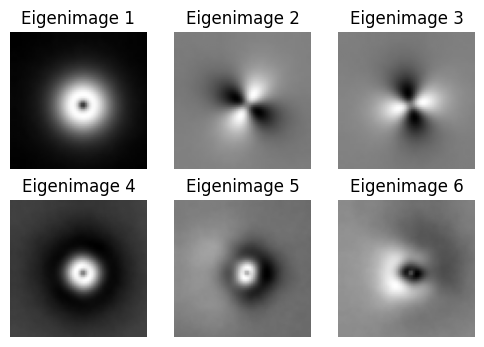

In [27]:
#eigenimages 
eigenimages = Vt[:6, :].reshape((6, 64, 64))
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
for i in range(6):
    axes[i//3, i%3].imshow(eigenimages[i], cmap='gray')
    axes[i//3, i%3].set_title(f"Eigenimage {i+1}")
    axes[i//3, i%3].axis('off')
plt.show()

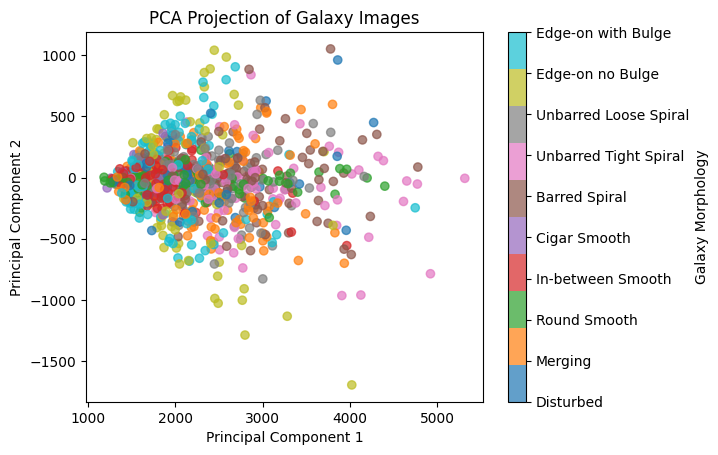

In [41]:
V2 = Vt[:2, :].T      
Z =  flat_x @ V2       
indices = np.random.choice(len(Z), 1000, replace=False)
scatter = plt.scatter(Z[indices, 0], Z[indices, 1], c=labels[indices], cmap='tab10', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Galaxy Images')
# 2. Add the colorbar and capture it in a variable
cbar = plt.colorbar(scatter)

# 3. Set the ticks to be in the middle of each color segment
# Since you have 10 classes, ticks are at 0, 1, ..., 9
cbar.set_ticks(range(10))

# 4. Map those ticks to your CLASS_NAMES list
cbar.set_ticklabels(CLASS_NAMES)

cbar.set_label('Galaxy Morphology')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Galaxy Images')
plt.show()   

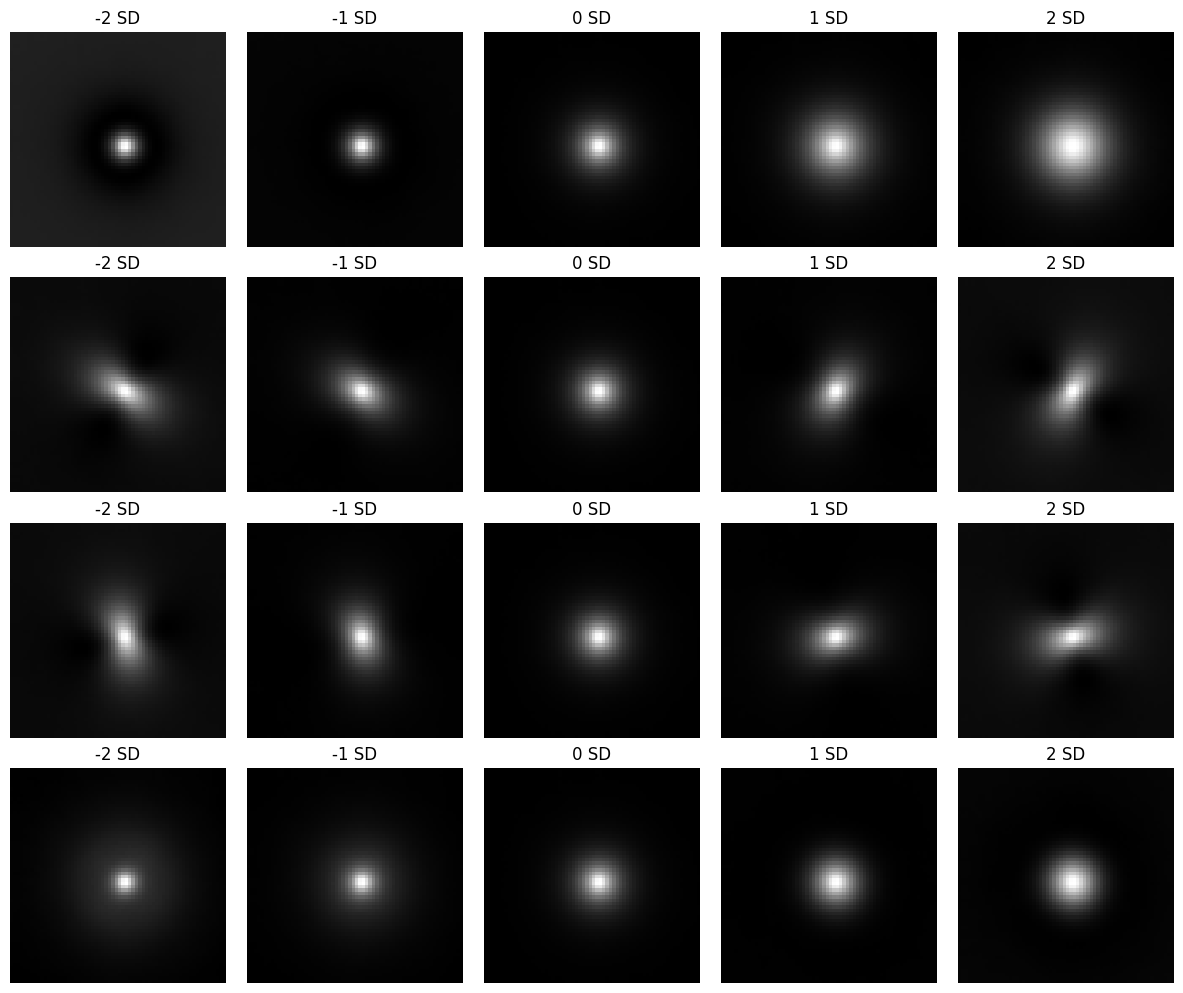

In [42]:
v4 = Vt[:4, :].T
Z4 = xcentered @ v4
sds = np.std(Z4, axis=0)

steps = [-2, -1, 0, 1, 2]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for j in range(4):
    for i, a in enumerate(steps):
        z = np.zeros(4)
        z[j] = a * sds[j]

        xhat = xmean + v4 @ z
        img = xhat.reshape(64, 64)

        axes[j, i].imshow(img, cmap='gray')
        axes[j, i].axis('off')
        axes[j, i].set_title(f'{a} SD')

for j in range(4):
    axes[j, 0].set_ylabel(f'PC{j+1}', rotation=90, size=12)

plt.tight_layout()
plt.show()


Q4  

In [43]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [44]:
print('Loaded:', gray_images.shape, '  dtype:', gray_images.dtype)
normalized_images = gray_images / 255.0
print('Pixel range: [{:.3f}, {:.3f}]'.format(normalized_images.min(), normalized_images.max()))

Loaded: (17736, 64, 64)   dtype: float64
Pixel range: [0.029, 1.000]


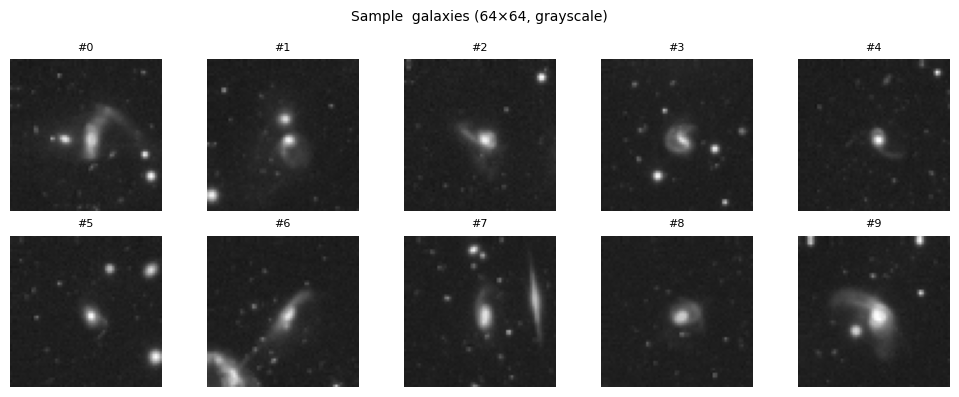

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(normalized_images[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'#{i}', fontsize=8)
plt.suptitle('Sample  galaxies (64×64, grayscale)', fontsize=10)
plt.tight_layout()
plt.show()

In [46]:
N_TRAIN    = 14000
BATCH_SIZE = 32

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(normalized_images[:N_TRAIN,  None, :, :], dtype=torch.float32)
x_val   = torch.tensor(normalized_images[N_TRAIN:,  None, :, :], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([14000, 1, 64, 64])
Validation images: torch.Size([3736, 1, 64, 64])


In [47]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8          # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s     # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,       64,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,       128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)                      # (N, 128, s, s)
        h = h.view(h.size(0), -1)                 # (N, 128*s*s)  flatten
        return self.enc_fc(h)                      # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)                         # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s) # (N, 128, s, s)  reshape
        return self.dec_conv(h)                    # (N, channels, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

In [48]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [49]:
EPOCHS = 50

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

    


        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.') 

Epoch   5/50  train loss: 0.00268  val loss: 0.00334
Epoch  10/50  train loss: 0.00257  val loss: 0.00323
Epoch  15/50  train loss: 0.00250  val loss: 0.00328
Epoch  20/50  train loss: 0.00244  val loss: 0.00323
Epoch  25/50  train loss: 0.00239  val loss: 0.00308
Epoch  30/50  train loss: 0.00235  val loss: 0.00330
Epoch  35/50  train loss: 0.00232  val loss: 0.00330
Epoch  40/50  train loss: 0.00229  val loss: 0.00330
Epoch  45/50  train loss: 0.00226  val loss: 0.00341
Epoch  50/50  train loss: 0.00225  val loss: 0.00335
Training complete.


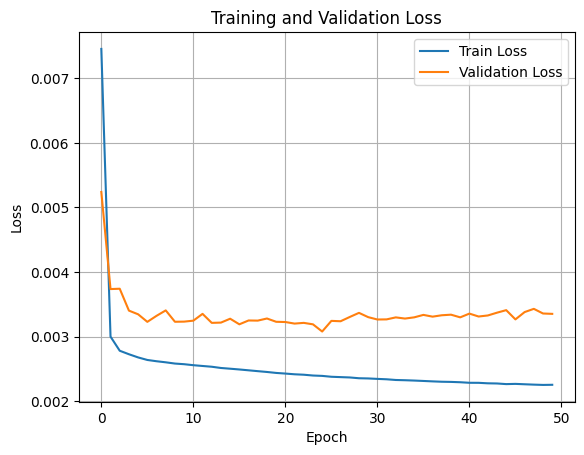

In [50]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')   
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

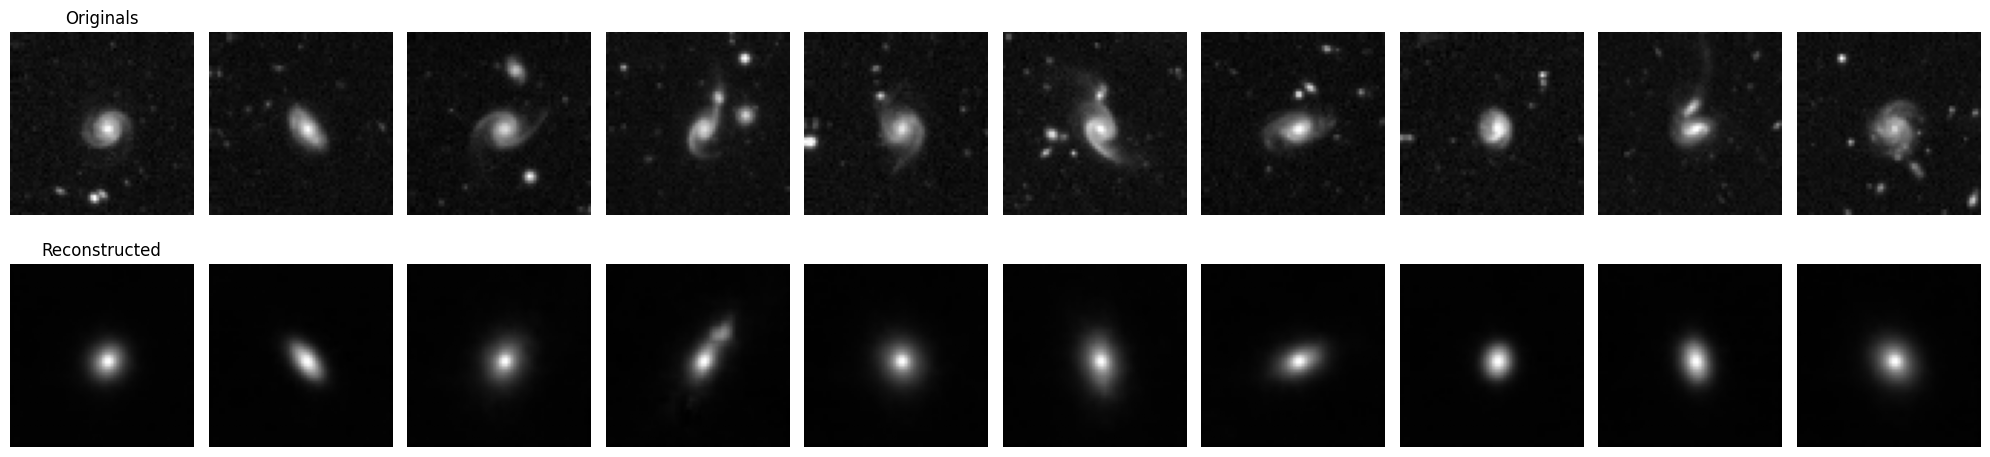

In [53]:
model.eval()
with torch.no_grad():
    # Pass the validation batch through the model
    reconstructed = model(x_val_dev)

original_np = x_val_dev.cpu().numpy()
recon_np = reconstructed.cpu().numpy()

# Create one large figure
plt.figure(figsize=(20, 5))

for j in range(10):
    # --- Top Row: Original Images ---
    plt.subplot(2, 10, j + 1)
    plt.imshow(original_np[j].reshape(64, 64), cmap='gray')
    if j == 0: 
        plt.title("Originals") # Only put title on the first one to save space
    plt.axis('off')

    # --- Bottom Row: Reconstructed Images ---
    # j + 11 shifts the plot to the second row (indices 11 through 20)
    plt.subplot(2, 10, j + 11) 
    plt.imshow(recon_np[j].reshape(64, 64), cmap='gray')
    if j == 0:
        plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [52]:
ANN_mse = loss_fn(reconstructed, x_val_dev).item()
print(f'Mean Squared Error on validation set: {ANN_mse:.5f}') 

Mean Squared Error on validation set: 0.00335


In [59]:
flat_x_norm = normalized_images.reshape(normalized_images.shape[0], -1)

# fit SVD on training data only
train_flat = flat_x_norm[:N_TRAIN]
val_flat   = flat_x_norm[N_TRAIN:]

xmean = np.mean(train_flat, axis=0)
train_centered = train_flat - xmean
val_centered   = val_flat - xmean

U, S, Vt = np.linalg.svd(train_centered, full_matrices=False)

k = 4
Vk = Vt[:k, :]

# project validation data onto training PCs, then reconstruct
Z_val = val_centered @ Vk.T
val_reconstructed = Z_val @ Vk + xmean

svd_val_mse = np.mean((val_flat - val_reconstructed) ** 2)
print("Validation MSE (SVD):", svd_val_mse)


Validation MSE (SVD): 0.003567092489238195


In [60]:
ANN_mse_rescaled = ANN_mse * 255**2
print(f'Mean Squared Error on validation set (rescaled to pixel range): {ANN_mse_rescaled:.2f}')
svd_val_mse_rescaled = svd_val_mse * 255**2
print(f'Mean Squared Error on validation set (SVD, rescaled): {svd_val_mse_rescaled:.2f}')

Mean Squared Error on validation set (rescaled to pixel range): 217.92
Mean Squared Error on validation set (SVD, rescaled): 231.95
